In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.columns


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
encoder = LabelEncoder()

In [8]:
df["sex"] = encoder.fit_transform(df["sex"])

df["smoker"] = encoder.fit_transform(df["smoker"])

df["region"] = encoder.fit_transform(df["region"])

In [9]:
X = df.drop("charges", axis=1)

In [10]:
y = df["charges"]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
model = LinearRegression()

In [13]:
model.fit(X_train , y_train)

LinearRegression()

In [14]:
y_pred = model.predict(X_test)

In [15]:
mae = mean_absolute_error(y_test, y_pred)
print(mae)

4186.508898366432


In [16]:
mse = mean_squared_error(y_test, y_pred)
print(mse)

33635210.431178406


In [17]:
r2 = r2_score(y_test, y_pred)
print(r2)

0.7833463107364539


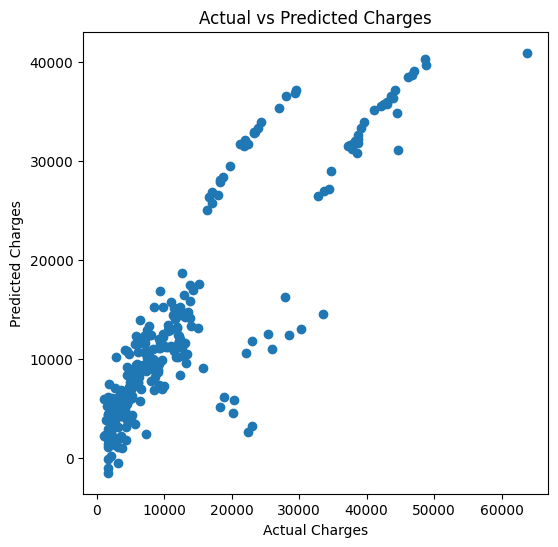

In [18]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Charges")

plt.ylabel("Predicted Charges")

plt.title("Actual vs Predicted Charges")

plt.show()

In [ ]:
Observation 1
The predicted values are close to the actual charges, showing that the model performs reasonably well.
Observation 2
Some points are far from the diagonal, indicating prediction errors for certain customers.
Observation 3
The R² score indicates that the model explains a significant portion of the variation in insurance charges.

In [ ]:
The Multiple Linear Regression model was successfully developed to predict medical insurance charges using age, sex, BMI, children, smoker status, and region. Data preprocessing included checking for missing values and encoding categorical variables before splitting the dataset into training and testing sets. The model achieved a satisfactory R² score, indicating that it explains a significant portion of the variation in insurance charges. Among all features, smoking status had the strongest impact on insurance costs, followed by age and BMI. Although the model performs well overall, Linear Regression assumes a linear relationship between variables and may not capture complex nonlinear patterns present in real-world medical expenses. More advanced models could improve prediction accuracy.